uploading dataset

In [2]:
import pandas as pd

df = pd.read_csv("D:/AI_trend_analysis/data/ai_adoption_dataset.csv")

print(df.head())
print(df.info())

     country        industry           ai_tool  adoption_rate  \
0        USA      Technology           ChatGPT          40.45   
1     France   Manufacturing        Midjourney          35.72   
2  Australia  Transportation           ChatGPT          13.47   
3         UK   Manufacturing           ChatGPT          48.46   
4         UK     Agriculture  Stable Diffusion          34.06   

   daily_active_users  year  \
0                2461  2023   
1                8496  2024   
2                8641  2024   
3                3488  2023   
4                1124  2024   

                                       user_feedback age_group company_size  
0  YyvLXOFyevRMSvJtkXodLvgejiqQNvSOZfeeJASDOVTxwm...     35-44      Startup  
1  AdFVhenjthYSKJNzxzfaGQk wLnjRCgrHTyfXQEFjFJCMO...     18-24   Enterprise  
2  zgNPmXBICRNbpjpTqIUWmMTeTYsInDNtAmzuxpDvcUZEAi...     45-54      Startup  
3  LxeKzQFbPvhxXUSgPVlLLJ pUFaicjCgiMtAmsTjovkrdE...     45-54   Enterprise  
4  IOQtQoSKdSmiXRsUKpjXjXZgQohym

PHASE-1 Data Understanding

1.Dataset information

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145000 entries, 0 to 144999
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   country             145000 non-null  str    
 1   industry            145000 non-null  str    
 2   ai_tool             145000 non-null  str    
 3   adoption_rate       145000 non-null  float64
 4   daily_active_users  145000 non-null  int64  
 5   year                145000 non-null  int64  
 6   user_feedback       145000 non-null  str    
 7   age_group           145000 non-null  str    
 8   company_size        145000 non-null  str    
dtypes: float64(1), int64(2), str(6)
memory usage: 10.0 MB


2.Shape

In [20]:
df.shape

(145000, 9)

3.Missing Values

In [21]:
df.isnull().sum()

country               0
industry              0
ai_tool               0
adoption_rate         0
daily_active_users    0
year                  0
user_feedback         0
age_group             0
company_size          0
dtype: int64

4.Duplicate Records

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df = df.drop_duplicates()

5.Statistical Summary

In [24]:
df.describe()

,adoption_rate,daily_active_users,year
count,145000.000000,145000.000000,145000.000000
mean,49.873025,5039.302683,2023.703117
std,28.842523,2858.124918,0.456886
min,0.000000,100.000000,2023.000000
25%,24.930000,2566.000000,2023.000000
50%,49.760000,5036.000000,2024.000000
75%,74.840000,7515.000000,2024.000000
max,100.000000,9999.000000,2024.000000


Question 1: Number of Organizations

In [25]:
len(df)

145000

Question 2: Most Commonly Used AI Tools

In [26]:
df['ai_tool'].value_counts()

ai_tool
ChatGPT             58045
Midjourney          43324
Stable Diffusion    21826
Bard                14519
Claude               7286
Name: count, dtype: int64

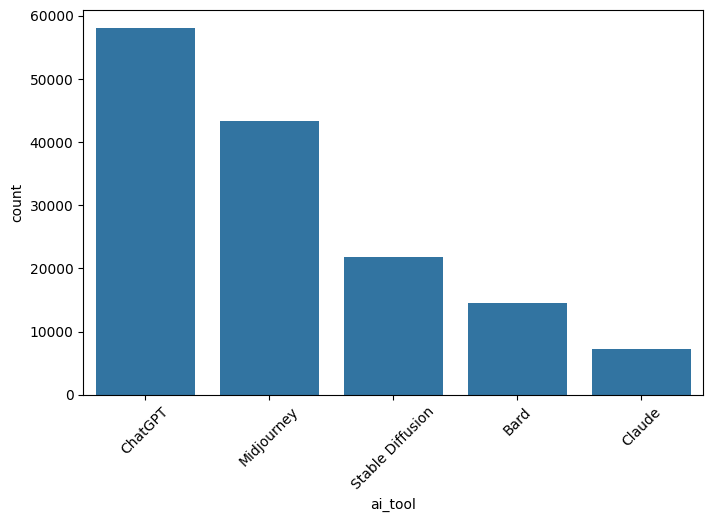

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='ai_tool')

plt.xticks(rotation=45)
plt.savefig('../images/Most_commenly_used_AI.png')
plt.show()

Question 3: Adoption Distribution by Industry

In [28]:
df['industry'].value_counts()

industry
Manufacturing     18267
Education         18200
Transportation    18158
Technology        18134
Finance           18124
Healthcare        18118
Retail            18053
Agriculture       17946
Name: count, dtype: int64

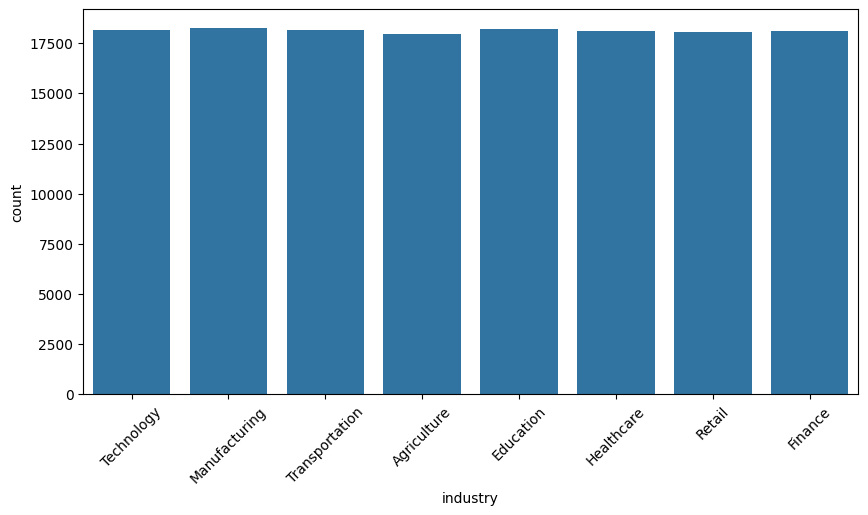

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='industry')

plt.xticks(rotation=45)
plt.savefig('../images/Adoption_distribution.png')
plt.show()

Phase-2 Descriptive Statistical Analysis 

Adoption Rate Statistics

Mean

In [3]:
df["adoption_rate"].mean()

np.float64(49.87302496551724)

Median

In [31]:
df["adoption_rate"].median()


np.float64(49.76)

Standard Deviation

In [13]:
df["adoption_rate"].std()

np.float64(28.842522764871514)

Quartiles

In [14]:
df["adoption_rate"].quantile([0.25,0.5,0.75])

0.25    24.93
0.50    49.76
0.75    74.84
Name: adoption_rate, dtype: float64

Percentiles

In [33]:
import numpy as np
np.percentile(df['adoption_rate'],[10,25,50,75,90])

array([ 9.96, 24.93, 49.76, 74.84, 89.93])

Distribution of Company Size

In [34]:
df['company_size'].value_counts()

company_size
Startup       48601
Enterprise    48279
SME           48120
Name: count, dtype: int64

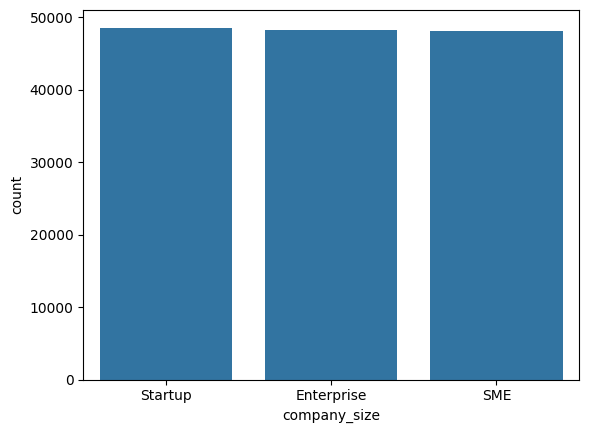

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df,x='company_size')
plt.savefig('../images/Distribution_of_company_size.png')
plt.show()

Phase 3 – Trend Investigation

Industry vs Adoption

In [17]:
industry_adoption = df.groupby('industry')['adoption_rate'].mean()

industry_adoption.sort_values(ascending=False)

industry
Agriculture       50.329049
Technology        50.017133
Finance           49.960481
Healthcare        49.868791
Transportation    49.842929
Education         49.788982
Retail            49.607140
Manufacturing     49.575804
Name: adoption_rate, dtype: float64

Bar Chart

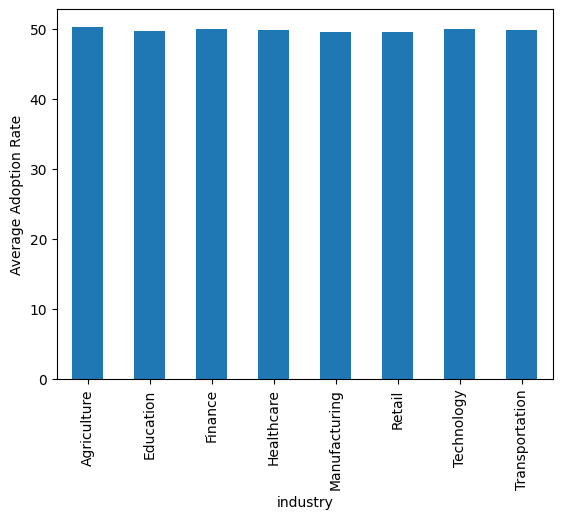

In [18]:
import matplotlib.pyplot as plt
industry_adoption.plot(kind='bar')

plt.ylabel("Average Adoption Rate")
plt.savefig('../images/Industry_adoption.png')
plt.show()

Company Size vs Adoption

In [20]:
size_adoption = df.groupby('company_size')['adoption_rate'].mean()

size_adoption

company_size
Enterprise    49.836855
SME           49.743258
Startup       50.037439
Name: adoption_rate, dtype: float64

visulaization

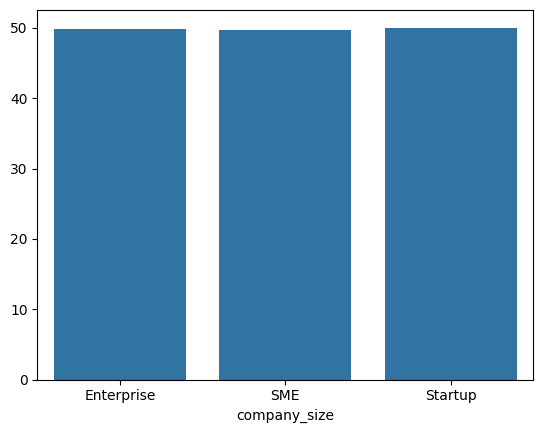

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(
    x=size_adoption.index,
    y=size_adoption.values
)
plt.savefig('../images/company_size_vs_adoption.png')
plt.show()

AI Tool vs Adoption

In [23]:
tool_adoption = df.groupby('ai_tool')['adoption_rate'].mean()

tool_adoption

ai_tool
Bard                49.813313
ChatGPT             49.909742
Claude              50.196582
Midjourney          49.896495
Stable Diffusion    49.660500
Name: adoption_rate, dtype: float64

Visualization

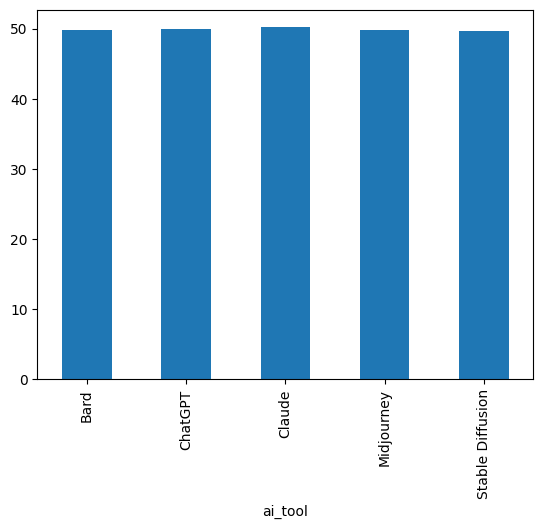

In [24]:
tool_adoption.plot(kind='bar')
plt.savefig('../images/AI_tool_adoption.png')

Adoption Year vs Growth

In [26]:
year_growth = df.groupby('year')['adoption_rate'].mean()

year_growth

year
2023    50.022059
2024    49.810097
Name: adoption_rate, dtype: float64

Line Chart

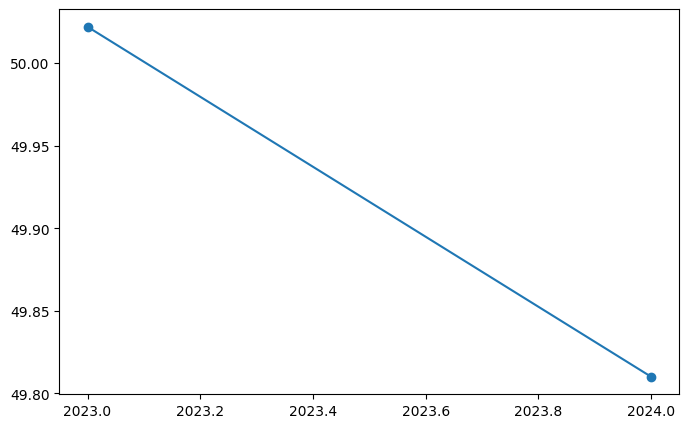

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    year_growth.index,
    year_growth.values,
    marker='o'
)
plt.savefig('../images/Adoption_year_vs_growth.png')
plt.show()

Phase 4 – Correlation Analysis

Numeric Columns

In [29]:
numeric_df = df[
[
'adoption_rate',
'daily_active_users',
'year'
]
]
numeric_df

,adoption_rate,daily_active_users,year
0,40.45,2461,2023
1,35.72,8496,2024
2,13.47,8641,2024
3,48.46,3488,2023
4,34.06,1124,2024
...,...,...,...
144995,86.93,7921,2023
144996,51.99,6301,2024
144997,47.35,4726,2023
144998,31.87,2481,2024


Correlation Matrix

In [30]:
corr = numeric_df.corr()

corr

,adoption_rate,daily_active_users,year
adoption_rate,1.000000,0.002163,-0.003358
daily_active_users,0.002163,1.000000,0.001017
year,-0.003358,0.001017,1.000000


Heatmap

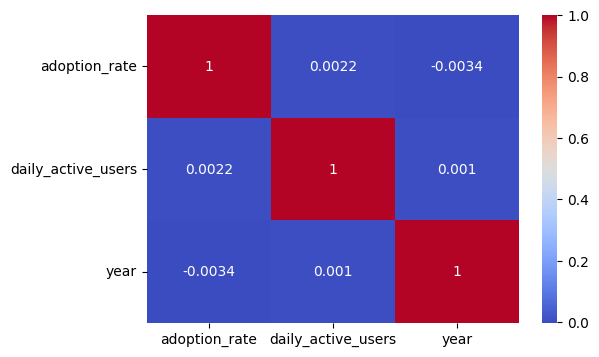

In [31]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.savefig('../images/Correation_matrix.png')
plt.show()

Adoption vs Daily Active Users

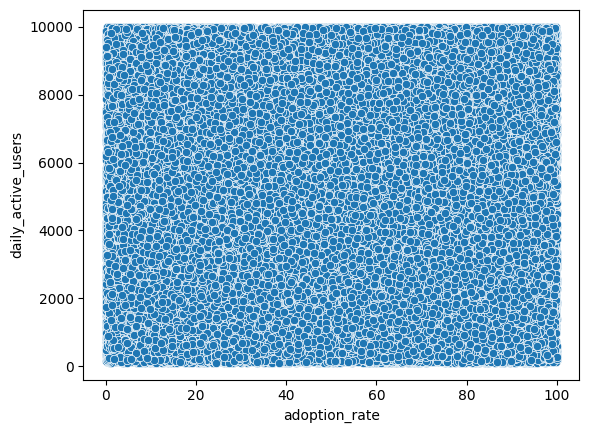

In [32]:
sns.scatterplot(
    data=df,
    x='adoption_rate',
    y='daily_active_users'
)
plt.savefig('../images/Adoption_vs_daily_active_users.png')
plt.show()

Does AI Adoption Improve Usage?

In [50]:
df[['adoption_rate',
    'daily_active_users']].corr()

,adoption_rate,daily_active_users
adoption_rate,1.000000,0.002163
daily_active_users,0.002163,1.000000


Phase 5 – Hypothesis Testing

In [55]:
import scipy.stats as stats
startup = df[
df['company_size']=='Startup'
]['adoption_rate']

sme = df[
df['company_size']=='SME'
]['adoption_rate']

enterprise = df[
df['company_size']=='Enterprise'
]['adoption_rate']

f_stat,p_value = stats.f_oneway(
    startup,
    sme,
    enterprise
)

print(f_stat)
print(p_value)

1.3146328403081209
0.2685761154627768


Interpretation

In [56]:
p_value < 0.05

np.False_

Phase 6 – Organization Segmentation

In [36]:
df['adoption_category'] = pd.cut(
    df['adoption_rate'],
    bins=[0,40,70,100],
    labels=[
        'Slow Adopters',
        'Early Adopters',
        'AI Leaders'
    ]
)

Check Counts

In [37]:
df['adoption_category'].value_counts()

adoption_category
Slow Adopters     58289
Early Adopters    43533
AI Leaders        43172
Name: count, dtype: int64

Visualization

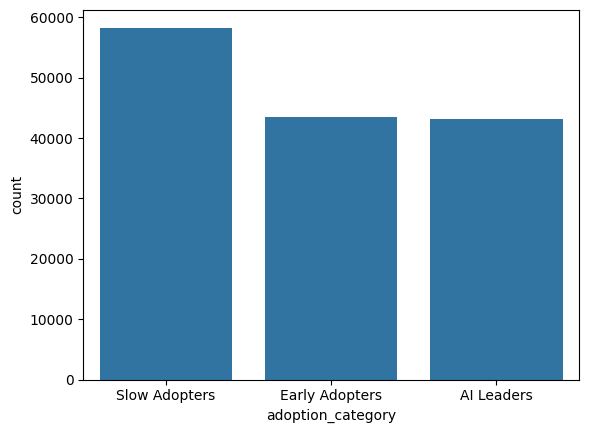

In [38]:
sns.countplot(
    data=df,
    x='adoption_category'
)
plt.savefig('../images/check_count.png')
plt.show()

Phase 7 – Business Insights

Insight 1

Which industries adopt AI most?

In [60]:
df.groupby('industry')['adoption_rate'].mean().sort_values(ascending=False)

industry
Agriculture       50.329049
Technology        50.017133
Finance           49.960481
Healthcare        49.868791
Transportation    49.842929
Education         49.788982
Retail            49.607140
Manufacturing     49.575804
Name: adoption_rate, dtype: float64

Insight 2

Which AI tools are most popular?

In [61]:
df['ai_tool'].value_counts()

ai_tool
ChatGPT             58045
Midjourney          43324
Stable Diffusion    21826
Bard                14519
Claude               7286
Name: count, dtype: int64

Insight 3

Do larger companies adopt AI faster?

In [62]:
df.groupby('company_size')['adoption_rate'].mean()

company_size
Enterprise    49.836855
SME           49.743258
Startup       50.037439
Name: adoption_rate, dtype: float64

Insight 4

Which age groups use AI most?

In [63]:
df.groupby('age_group')['daily_active_users'].mean()

age_group
18-24    5042.279149
25-34    5035.965452
35-44    5024.468188
45-54    5020.849305
55+      5072.323919
Name: daily_active_users, dtype: float64

Insight 5

Growth Trend Over Years

In [64]:
df.groupby('year')['adoption_rate'].mean()

year
2023    50.022059
2024    49.810097
Name: adoption_rate, dtype: float64